# Final Assignment - Computational Macroeconomics
### Student: Binyam Yohannes Olango
### ID: 4767382
### Date: 03 Aug 2026

---

## Overview
This notebook contains my full solutions to the Final Assignment.  
All notations and formulas follows the assignment sheet.


In [2]:
# Importing packages needed for the tasks
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import statsmodels.api as sm


## Task 1


In [3]:
# Defining parameters
sigma= 1
kappa=0.3
beta=0.995
phi_pi=1.5
phi_y=0.1
rho_mu=0.7


def model(z_t, Ez_t1, z_tm1, u_t):
    """
    Computes the residuals of the model equation: A z_t = M E_t[z_{t+1}] + D z_{t-1} + u_t

    Inputs:
    z_t: vector of current-period variables [mu_t, y_t, pi_t, i_t]
    Ez_t1: vector of expected next-period variables E_t[z_{t+1}]
    z_tm1: vector of lagged variables z_{t-1}
    u_t: vector of shocks

    Return: vector of residuals.
    """

    # Contribution of current-period variables
    left = A @ z_t

    # Contribution of expected future variables, lagged variables, and shocks
    right = M @ Ez_t1 + D @ z_tm1 + u_t

    # Residuals: must be zero for the model to hold
    return left - right

# Writing Matrix A which contains the coefficients on current-period variables
A = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 1/sigma],
    [-1, -kappa, 1, 0],
    [0, 0, 0, 1]
], dtype=float)

# Writing Matrix M which contains the coefficients on expected future variables
M = np.array([
    [0, 0, 0, 0],
    [0, 1, 1/sigma, 0],
    [0, 0, beta, 0],
    [0, 0, 0, 0]
], dtype=float)

# Writing Matrix D which contains the coefficients on lagged variables
D = np.array([
    [rho_mu, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, phi_y, phi_pi, 0]
], dtype=float)


## Task 2

In [4]:
def steady_state(z_guess):
    """
    In steady state: z_t = E_t[z_{t+1}] = z_{t-1} = z_guess, shocks (u_t) = 0

    Input: z_guess - a vector that containing trial values for these four variables: [mu, Y, pi, i]
    
    Return: The difference of implied z_t and z_guessed steady state values
    """
    
    # Creating a NumPy array from the input z_guess
    z_guess = np.array(z_guess, dtype=float)

    
    # With the above assumption calculate the right and left hand side of Equation 6 from the sheet separately
    right = M @ z_guess + D @ z_guess
    left = A @ z_guess

    return left - right

## Task 3


In [5]:
# Create an initial guess for the state vector.
# np.zeros(4) creates a NumPy array with elements value 0
z0 = np.zeros(4)

# fsolve attempts to find values of z such that: steady_state(z) = [0, 0, 0, 0]
z_ss = fsolve(steady_state, z0)


Because the steady state of the model is exactly zero, the MSV solution does not need a constant term. A constant term would only be required if the model converged to a non‑zero steady state. Since fsolve shows that all steady‑state values are zero, the MSV solution can be written entirely as a linear function of lagged variables and shocks, with no additional constant needed to shift the solution.

## Task 4

In [6]:
def LTI(A, M, D, F_guess):
    """
    Applies the Linear Time Iteration (LTI) algorithm to compute
    the matrices F and Q in the MSV solution:  z_t = F z_{t-1} + Q u_t

    Inputs:
    A, M, D = model matrices from Task 1
    F_guess = initial guess for F

    Return:
    F_new = matrix of coefficients on lagged variables
    Q = matrix of coefficients on shocks
    """

    # F_new = (A - M F_guess)^(-1) * D
    F_new = np.linalg.inv(A - M @ F_guess) @ D

    # Q = (A - M F_new)^(-1)
    Q = np.linalg.inv(A - M @ F_new)

    return F_new, Q


## Task 5

In [7]:
def solve_LTI(A, M, D, tol=1e-10, max_iter=500):
    """
    Repeatedly calls the LTI algorithm until F converges.
    
    Inputs:
    A, M, D      → model matrices from task 1
    tol          → convergence tolerance (how close F_new must be to F_old)
    max_iter     → maximum number of iterations allowed
    
    Returns:
    F            → converged matrix of coefficients on lagged variables
    Q            → matrix of coefficients on shocks
    """

    # Step 1: Start with an initial guess for F and Q (zero matrix is standard)
    F_old = np.zeros_like(A)
    Q = np.zeros_like(A)  # initial value

    # Step 2: Iterate the LTI update until convergence
    for iteration in range(max_iter):

        # Call the LTI function from Task 4
        F_new, Q = LTI(A, M, D, F_old)

        # Step 3: Check convergence
        # If the difference between F_new and F_old is tiny, we stop
        if np.max(np.abs(F_new - F_old)) < tol:
            print(f"Converged after {iteration+1} iterations.")
            return F_new, Q

        # Step 4: Update F_old for the next iteration
        F_old = F_new

    # If we reach max_iter without converging, warn the user
    print("Warning: LTI did not converge within max_iter.")
    return F_old, Q


## Task 6


In [8]:
# Calling the solve_LTI function to get the F and Q
F, Q = solve_LTI(A, M, D)

# Columns of F correspond to lagged state variables [mu_{t-1}, y_{t-1}, pi_{t-1}, i_{t-1}]
C_mu   = F[:, 0]
C_y    = F[:, 1]
C_pi   = F[:, 2]

# Columns of Q correspond to components of shocks vector u_t = [eps_mu, 0, 0, eps_i]
C_eps_mu = Q[:, 0]
C_eps_i  = Q[:, 3]


Converged after 37 iterations.


## Task 7

In [9]:
# Impulse responses to a one-time shock to eps_mu_t

T = 30  # number of periods for the Impulse Response Function

# Arrays to store the paths of mu, Y, pi, i
mu_path_mu = np.zeros(T)
Y_path_mu  = np.zeros(T)
pi_path_mu = np.zeros(T)
i_path_mu  = np.zeros(T)

# Initial state at t = -1 (before the shock): all variables (mu, Y, pi, i) at steady state (zero)
z_tm1 = np.zeros(4)

# Size of the one-time shock to eps_mu_t at t = 0
eps_mu_t = 0.01

for t in range(T):
    if t == 0:
        # At t = 0: one-time shock to eps_mu_t, no shock to eps_i_t
        # u_t = [eps_mu_t, 0, 0, eps_i_t], we got this shocks vector by deriving from the model equation
        u_t = np.array([eps_mu_t, 0.0, 0.0, 0.0])
    else:
        # After t = 0: no more shocks
        u_t = np.zeros(4)

    # Apply MSV solution: z_t = C_mu*mu_{t-1} + C_y*y_{t-1} + C_pi*pi_{t-1} + C_eps_mu*eps_mu_t + C_eps_i*eps_i_t
    z_t = (
        C_mu * z_tm1[0]
        + C_y * z_tm1[1]
        + C_pi * z_tm1[2]
        + C_eps_mu * u_t[0]
        + C_eps_i * u_t[3]
    )

    # Store each variable's path
    mu_path_mu[t] = z_t[0]
    Y_path_mu[t]  = z_t[1]
    pi_path_mu[t] = z_t[2]
    i_path_mu[t]  = z_t[3]

    # Update lagged state for next period
    z_tm1 = z_t

print('First 5 periods of the impulse responses to a 0.01 shock to eps_mu_t:')
print(np.column_stack([mu_path_mu, Y_path_mu, pi_path_mu, i_path_mu])[:5])


First 5 periods of the impulse responses to a 0.01 shock to eps_mu_t:
[[ 0.01       -0.01601607  0.00995374  0.        ]
 [ 0.007      -0.02079855  0.00478248  0.01332901]
 [ 0.0049     -0.01151179  0.00404225  0.00509386]
 [ 0.00343    -0.00902676  0.00260883  0.0049122 ]
 [ 0.002401   -0.00601091  0.00189634  0.00301057]]


## Task 8

In [10]:
# Impulse responses to a one-time shock to eps_i_t

T = 30  # number of periods for the Impulse Response Function

# Arrays to store the paths of mu, Y, pi, i
mu_path_i = np.zeros(T)
Y_path_i  = np.zeros(T)
pi_path_i = np.zeros(T)
i_path_i  = np.zeros(T)

# Initial state at t = -1 (before the shock): all variables at steady state (zero)
z_tm1 = np.zeros(4)

# Size of the one-time shock to eps_i_t at t = 0
eps_i_t = 0.01

for t in range(T):
    if t == 0:
        # At t = 0: one-time shock to eps_i_t, no shock to eps_mu_t
        u_t = np.array([0.0, 0.0, 0.0, eps_i_t])
    else:
        # After t = 0: no more shocks
        u_t = np.zeros(4)

    # Apply the MSV solution using the vectors C_mu, C_y, C_pi, C_eps_mu and C_eps_i
    z_t = (
        C_mu * z_tm1[0]
        + C_y * z_tm1[1]
        + C_pi * z_tm1[2]
        + C_eps_mu * u_t[0]
        + C_eps_i * u_t[3]
    )

    # Store each variable's path
    mu_path_i[t] = z_t[0]
    Y_path_i[t]  = z_t[1]
    pi_path_i[t] = z_t[2]
    i_path_i[t]  = z_t[3]

    # Update lagged state for next period
    z_tm1 = z_t

print('First 5 periods of the impulse responses to a 0.01 shock to eps_i_t:')
print(np.column_stack([mu_path_i, Y_path_i, pi_path_i, i_path_i])[:5])


First 5 periods of the impulse responses to a 0.01 shock to eps_i_t:
[[ 4.91748627e-19 -7.19280614e-03 -1.63938939e-03  1.00000000e-02]
 [ 4.48421138e-19  2.28613612e-03  5.21057738e-04 -3.17836470e-03]
 [ 2.80777158e-19 -7.26617435e-04 -1.65611153e-04  1.01020022e-03]
 [ 2.07070004e-19  2.30945521e-04  5.26372642e-05 -3.21078472e-04]
 [ 1.41603458e-19 -7.34029092e-05 -1.67300423e-05  1.02050448e-04]]


## Task 9

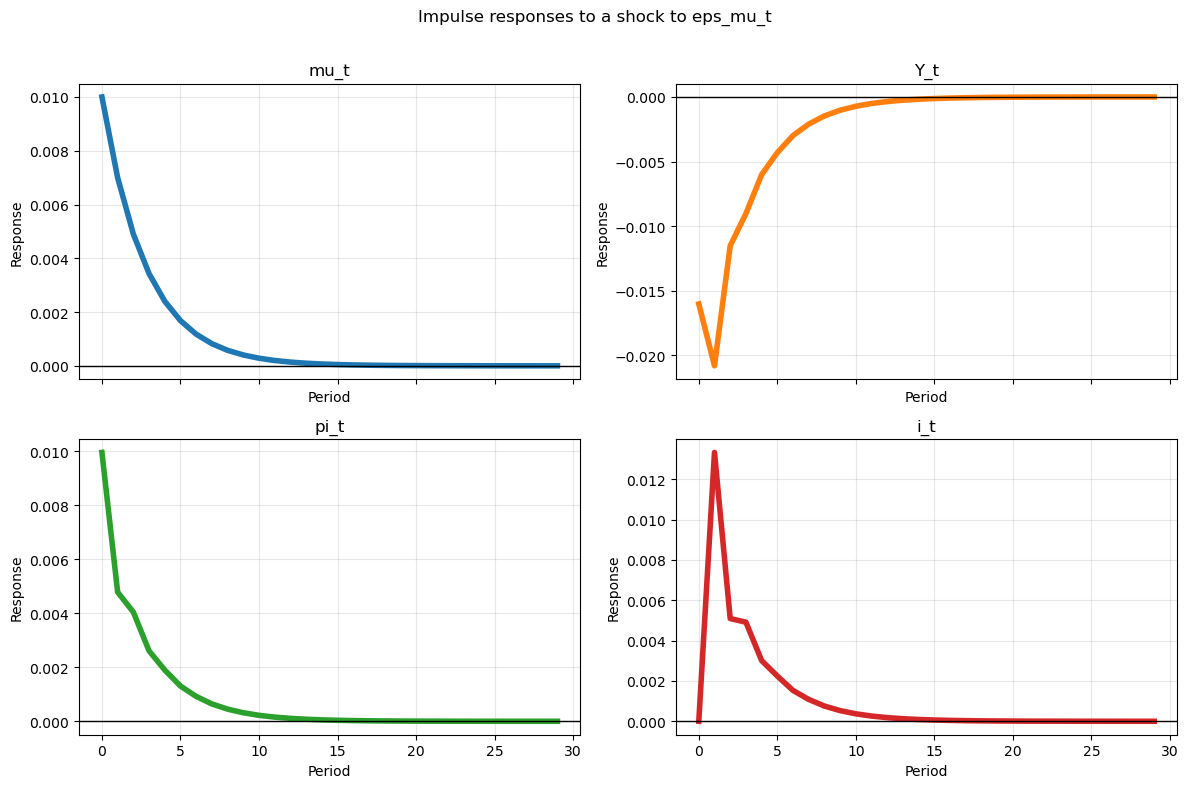

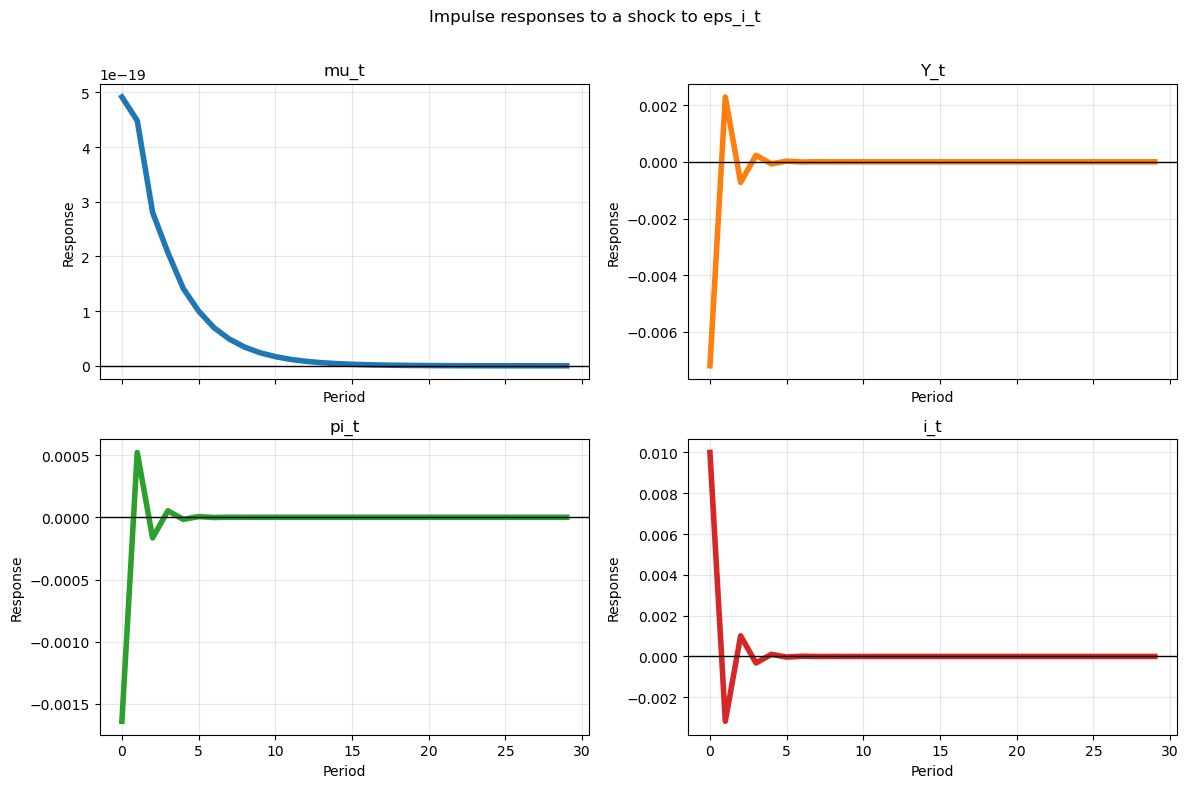

In [11]:
# Create a color list for the four subfigures
colors = ["C0", "C1", "C2", "C3"]

# Plot the impulse responses to a one-time shock to eps_mu_t
# Create a time index for the 30 periods of the IRF
periods = np.arange(T)

# Create a figure with four subfigures, one for each variable in z_t
fig_mu, axes_mu = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Store the four variables of the state vector in a list for plotting
variables_mu = [
    ("mu_t", mu_path_mu),
    ("Y_t", Y_path_mu),
    ("pi_t", pi_path_mu),
    ("i_t", i_path_mu),
]

# Plot each variable in its own subplot
for ax, (name, path), color in zip(axes_mu.flatten(), variables_mu, colors):
    ax.plot(periods, path, color=color, linewidth=4)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{name}")
    ax.set_xlabel("Period")
    ax.set_ylabel("Response")
    ax.grid(True, alpha=0.3)

# Add a title to the full figure and adjust the layout
fig_mu.suptitle("Impulse responses to a shock to eps_mu_t", fontsize=12)
fig_mu.tight_layout(rect=(0, 0, 1, 0.97))

# Plot the impulse responses to a one-time shock to eps_i_t
periods = np.arange(T)

# Create a figure with four subfigures, one for each variable in z_t
fig_i, axes_i = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Store the four variables of the state vector in a list for plotting
variables_i = [
    ("mu_t", mu_path_i),
    ("Y_t", Y_path_i),
    ("pi_t", pi_path_i),
    ("i_t", i_path_i),
]

# Plot each variable in its own subplot
for ax, (name, path), color in zip(axes_i.flatten(), variables_i, colors):
    ax.plot(periods, path, color=color, linewidth=4)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{name}")
    ax.set_xlabel("Period")
    ax.set_ylabel("Response")
    ax.grid(True, alpha=0.3)

# Add a title to the full figure and adjust the layout
fig_i.suptitle("Impulse responses to a shock to eps_i_t", fontsize=12)
fig_i.tight_layout(rect=(0, 0, 1, 0.97))

# Display both figures
plt.show()


## Task 10


#### Shock to the auto‑correlated shock (eps_mu_t)

The auto‑correlated shock (eps_mu_t) produces smooth, monotonic adjustments. No oscillations. The system absorbs the persistent shock gradually.

- **mu:** jumps to about 0.01 and decays smoothly which is exactly what we expect from a persistent AR(1) shock. This shock represents a persistent disturbance to the IS curve. Because it is auto‑correlated, the economy feels its effect for several periods.  
- **Y:** drops sharply (close to –0.02) and returns slowly to zero. A persistent IS shock tightens demand conditions, so output falls initially and recovers only gradually.
- **pi:** rises on impact and then declines gradually. Lower demand reduces price pressure, but because the shock is persistent, inflation adjusts slowly.  
- **i:** increases (close to 0.012) and then converges smoothly. The Taylor rule reacts to higher inflation and output movements, so the interest rate rises and then declines as the shock fades.

---

#### Shock to the non‑auto‑correlated shock (eps_i_t)

The non‑auto‑correlated shock (eps_i_t) produces fast, oscillatory dynamics. The system over‑corrects because the shock has no persistence of its own.

- **mu:** rises and decays, but more sharply than under eps_mu_t. Even though the shock is to the interest rate, the IS curve reacts immediately, causing mu to move sharply. A sudden, non‑persistent rate shock causes demand to adjust quickly, overshoot, and then correct; hence the oscillation.  
- **Y:** jumps up, then swings below zero, then settles that is clear oscillation. Inflation responds to the abrupt change in demand and interest rates, overshoots, and then stabilizes.
- **pi:** spikes, dips slightly negative, then converges.  
- **i:**  Because eps_i_t is independent and identically distributed, the interest rate jumps sharply on impact and then corrects, producing the negative dip.

## Task 11

In [12]:
# Number of periods for the simulation
T = 500

# Standard deviations for the shocks
sigma_mu = 0.01   # std dev of eps_mu_t (innovation to mu_t)
sigma_i  = 0.01   # std dev of eps_i_t (innovation to i_t)

# Draw random shocks for each period
eps_mu_t = np.random.normal(0.0, sigma_mu, T)   # shock to mu_t
eps_i_t  = np.random.normal(0.0, sigma_i, T)    # shock to i_t

# Storage for simulated paths of mu, Y, pi, i
mu_sim = np.zeros(T)
Y_sim  = np.zeros(T)
pi_sim = np.zeros(T)
i_sim  = np.zeros(T)

# Initial state at t = -1 (steady state)
z_tm1 = np.zeros(4)

for t in range(T):

    # Shock vector u_t = [eps_mu_t, 0, 0, eps_i_t]
    u_t = np.array([eps_mu_t[t], 0.0, 0.0, eps_i_t[t]])

    # MSV solution using the C-vectors
    z_t = (
        C_mu * z_tm1[0]
        + C_y * z_tm1[1]
        + C_pi * z_tm1[2]
        + C_eps_mu * u_t[0]
        + C_eps_i * u_t[3]
    )

    # Store simulated values
    mu_sim[t] = z_t[0]
    Y_sim[t]  = z_t[1]
    pi_sim[t] = z_t[2]
    i_sim[t]  = z_t[3]

    # Update lagged state
    z_tm1 = z_t

# Create DataFrame with Y and pi
df = pd.DataFrame({
    "Y":  Y_sim,
    "pi": pi_sim
})


## Task 12


In [13]:
T = len(pi_sim)

# Array to store E_t pi_{t+1}
E_pi_next = np.zeros(T)

for t in range(T):
    # Under rational expectations, agents know current state (mu_t, Y_t, pi_t, i_t)
    # but future shocks eps_mu_{t+1}, eps_i_{t+1} have expectation zero.
    #
    # So we use the MSV solution one period ahead, setting future shocks to 0:
    # z_{t+1}^exp = C_mu * mu_t + C_y * Y_t + C_pi * pi_t
    #               + C_eps_mu * 0 + C_eps_i * 0
    z_exp_next = (
        C_mu * mu_sim[t]
        + C_y * Y_sim[t]
        + C_pi * pi_sim[t]
    )

    # The third element of z_exp_next is expected inflation pi_{t+1}
    E_pi_next[t] = z_exp_next[2]

# Add E_t pi_{t+1} to the DataFrame
df["E_pi_next"] = E_pi_next


Under rational expectations, agents use the current state and the MSV solution to forecast next‑period inflation, assuming future shocks have mean zero, so only the deterministic part of the MSV solution enters E_t[pi_{t+1}]

## Task 13

In [14]:
# pi_{t+1} is just pi shifted one period forward
pi_next = df["pi"].shift(-1)

# Forecast error: pi_{t+1} - E_t pi_{t+1}
df["fe_pi"] = pi_next - df["E_pi_next"]

## Task 14


In [16]:
# Drop the last observation because fe_pi[T] = NaN (no pi_{T+1})
df_reg = df.dropna(subset=["fe_pi"])

# Dependent variable: forecast error
y = df_reg["fe_pi"]

# Independent variable: inflation in period t
X = df_reg["pi"]

# Add constant for alpha
X = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  fe_pi   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     4.403
Date:                Tue, 04 Aug 2026   Prob (F-statistic):             0.0364
Time:                        01:36:06   Log-Likelihood:                 1589.0
No. Observations:                 499   AIC:                            -3174.
Df Residuals:                     497   BIC:                            -3166.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      0.905      0.3

The regression shows whether forecast errors are predictable from current inflation; under rational expectations we expect alpha close to 0 and beta close to 0, meaning agents do not make systematic or inflation‑dependent mistakes.